In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [23]:
merged_df=pd.read_csv("/Users/palakkakani/Desktop/ML/data/processed/merged_cleaned.csv")

In [24]:
merged_df['tenure_bucket'] = pd.cut(merged_df['months_active'], bins=[0,6,12,24,48,100],
                                    labels=['0-6','7-12','13-24','25-48','49+'])


In [25]:
tenure_ab = merged_df.groupby(['tenure_bucket','experiment_group'])['churn_label'].agg(['mean','count']).reset_index()
tenure_ab.rename(columns={'mean':'churn_rate','count':'num_users'}, inplace=True)
print(tenure_ab)

  tenure_bucket experiment_group  churn_rate  num_users
0           0-6          control    0.538141        721
1           0-6         discount    0.528705        749
2          7-12          control    0.348624        327
3          7-12         discount    0.367725        378
4         13-24          control    0.283433        501
5         13-24         discount    0.290631        523
6         25-48          control    0.190416        793
7         25-48         discount    0.217228        801
8           49+          control    0.090272       1141
9           49+         discount    0.100182       1098


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_43555/2653985331.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_ab = merged_df.groupby(['tenure_bucket','experiment_group'])['churn_label'].agg(['mean','count']).reset_index()


In [26]:
merged_df['engagement_score'] = merged_df['sessions_per_week'] + merged_df['avg_watch_minutes']/10

Engagement is very similar across groups, suggesting the discount did not strongly impact overall engagement.

In [27]:
engagement_summary = merged_df.groupby('experiment_group')['engagement_score'].agg(['mean','std','count'])
print(engagement_summary)

                      mean       std  count
experiment_group                           
control           9.077861  2.673114   3491
discount          8.988735  2.657534   3552


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_43555/2962387420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_group', y='engagement_score', data=merged_df, palette='Set2')


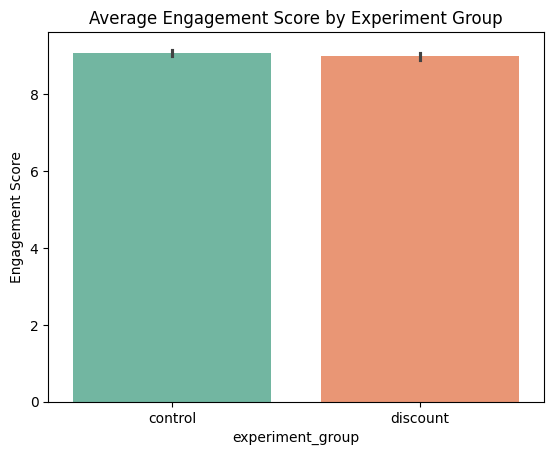

In [28]:
# Plot
sns.barplot(x='experiment_group', y='engagement_score', data=merged_df, palette='Set2')
plt.title("Average Engagement Score by Experiment Group")
plt.ylabel("Engagement Score")
plt.show()

                       mean        sum
experiment_group                      
control           62.034245  216561.55
discount          61.211768  217424.20


/var/folders/5f/yfl9x7p9311gz93ctr_bp39m0000gn/T/ipykernel_43555/1614403414.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment_group', y='monthly_revenue', data=merged_df, palette='Set3')


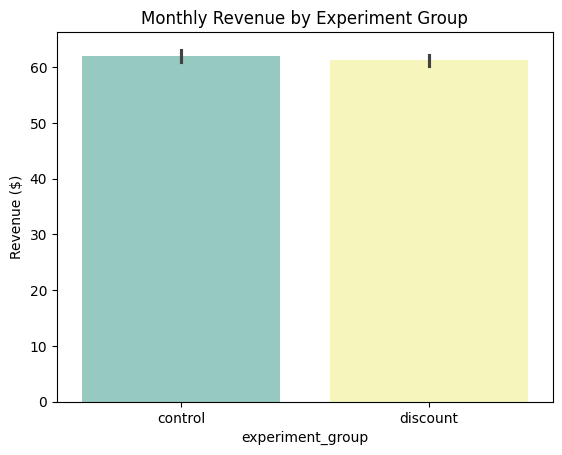

In [31]:
# Average revenue per user by group
ltv_summary = merged_df.groupby('experiment_group')['monthly_revenue'].agg(['mean','sum'])
print(ltv_summary)

# Plot revenue impact
sns.barplot(x='experiment_group', y='monthly_revenue', data=merged_df, palette='Set3')
plt.title("Monthly Revenue by Experiment Group")
plt.ylabel("Revenue ($)")
plt.show()

Z - Test

- All p-values > 0.05 → no statistically significant difference in churn between discount and control groups.
- Conclusion: Discounts did not have a meaningful impact on churn for any tenure segment.

In [32]:
for bucket in merged_df['tenure_bucket'].unique():
    seg = merged_df[merged_df['tenure_bucket']==bucket]
    count = np.array([seg[seg['experiment_group']=='discount']['churn_label'].sum(),
                      seg[seg['experiment_group']=='control']['churn_label'].sum()])
    nobs = np.array([len(seg[seg['experiment_group']=='discount']),
                     len(seg[seg['experiment_group']=='control'])])
    stat, pval = proportions_ztest(count, nobs)
    print(f"Tenure {bucket}: Z={stat:.3f}, p-value={pval:.4f}")

Tenure 0-6: Z=-0.363, p-value=0.7169
Tenure 25-48: Z=1.328, p-value=0.1840
Tenure 7-12: Z=0.527, p-value=0.5980
Tenure 13-24: Z=0.254, p-value=0.7991
Tenure 49+: Z=0.799, p-value=0.4243
Tenure nan: Z=nan, p-value=nan


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/proportion.py:1018: RuntimeWarning: invalid value encountered in scalar divide
  p_pooled = np.sum(count) * 1. / np.sum(nobs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/stats/proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)


In [33]:
control = merged_df[merged_df['experiment_group']=='control']['churn_label']
treatment = merged_df[merged_df['experiment_group']=='discount']['churn_label']

In [34]:
count = np.array([treatment.sum(), control.sum()])   # # of users who churned
nobs = np.array([len(treatment), len(control)])  

The discount group has slightly lower churn, but the difference is **not statistically significant**.

In [35]:
stat, pval = proportions_ztest(count, nobs)
print("Z-Statistic:", stat)
print("p-value:", pval)

Z-Statistic: 1.5332772673589086
p-value: 0.12520755326496769
